# Notebook 2: DEM Co-registration with xDEM

Co-registers all DEMs to SRTM 2000 as reference using the Nuth & Kääb (2011) method implemented in xDEM (xDEM Contributors, 2024).

**Reviewer note on stable terrain masking:**  
We use the UNION of 2000 and 2019 glacier outlines as the glacier mask, so terrain that was ice in 1954 but bare by 2000 is not incorrectly treated as stable ground (addresses reviewer comment on polygon year mismatch).

**CerroBlanco 2024 note:**  
All three co-registration methods (NuthKaab, ICP, VerticalShift) produced spurious or negligible corrections on CerroBlanco due to insufficient stable terrain within the small drone DEM footprint (~1,014 stable pixels, NuthKaab subsampled to 93). The aligned DEM already has a -2.5m offset from SRTM over Glaciar Nevado — negligible at 30m resolution — so no co-registration correction is applied. This is flagged in the summary CSV.

**INPUTS** (from Notebook 1):
- `aligned_dems/SRTM_2000_aligned.tif` ← reference
- `aligned_dems/<name>_aligned.tif` for all other DEMs
- Glacier shapefiles (DGA 2000 and 2019)
- `combined_mask_output.shp` — manually digitized stable areas

**OUTPUTS**:
- `coreg_dems_xdem/<name>_coreg.tif` ← co-registered DEMs
- `coreg_dems_xdem/coregistration_summary.csv`
- `coreg_dems_xdem/coregistration_qc.png`

In [ ]:
# ==============================================================================
# Imports and user variables
# ==============================================================================
import os
import shutil
import glob
import subprocess
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import Resampling
import rioxarray as rxr
import matplotlib.pyplot as plt
import xdem
import geoutils as gu

print(f'xDEM version: {xdem.__version__}')

aligned_dem_folder = 'aligned_dems_geoid'
output_folder = 'coreg_dems_demcoreg'
os.makedirs(output_folder, exist_ok=True)

glacier_1975_path  = '/Users/milliespencer/Desktop/70_Years_MB_Nevados/NdC_1975_glacier_poly/Shp/Nevados_Chillan_1975.shp'
glacier_2000_path  = 'example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp'
glacier_2019_path  = 'example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp'

reference_name = 'SRTM_2000'

source_dems = [
    'IGM_1954',
    'CerroBlanco_2024',
    'LasTermas_2024',
    'Pleiades_2025',
    'ASTER_20040326',
    'ASTER_20070224',
    'ASTER_20080330',
    'ASTER_20180301',
]

COREG_METHOD = 'nuthkaab'

xDEM version: 0.2.2


In [2]:
# ==============================================================================
# Step 1: Build glacier union mask
# Union of 1975 ∪ 2000 ∪ 2019 outlines — conservative masking so terrain
# that was ice in any inventory year is excluded from stable terrain.
# ==============================================================================
print('Building glacier union mask...')

gdf_1975 = gpd.read_file(glacier_1975_path)
gdf_2000 = gpd.read_file(glacier_2000_path)
gdf_2019 = gpd.read_file(glacier_2019_path)

# Reproject all to common CRS
for gdf in [gdf_2000, gdf_2019]:
    if gdf.crs != gdf_1975.crs:
        gdf = gdf.to_crs(gdf_1975.crs)

glacier_union = gpd.GeoDataFrame(
    geometry=[gdf_1975.union_all()
                      .union(gdf_2000.union_all())
                      .union(gdf_2019.union_all())],
    crs=gdf_1975.crs
)
glacier_union_path = os.path.join(output_folder, 'glacier_union_mask.shp')
glacier_union.to_file(glacier_union_path)
print(f'  1975 area: {gdf_1975.area.sum()/1e6:.2f} km²')
print(f'  2000 area: {gdf_2000.to_crs("EPSG:32719").area.sum()/1e6:.2f} km²')
print(f'  2019 area: {gdf_2019.to_crs("EPSG:32719").area.sum()/1e6:.2f} km²')
print(f'  Union area:{glacier_union.area.sum()/1e6:.2f} km²')
print(f'  Glacier union mask saved: {glacier_union_path}')

Building glacier union mask...
  1975 area: 16.02 km²
  2000 area: 2.91 km²
  2019 area: 1.90 km²
  Union area:16.34 km²
  Glacier union mask saved: coreg_dems_demcoreg/glacier_union_mask.shp


In [3]:
# ==============================================================================
# Step 2: Load reference DEM
# ==============================================================================
ref_path = os.path.join(aligned_dem_folder, f'{reference_name}_aligned.tif')
print(f'Loading reference DEM: {ref_path}')
reference_dem = xdem.DEM(ref_path)
print(f'  CRS: {reference_dem.crs}  |  Resolution: {reference_dem.res} m')

Loading reference DEM: aligned_dems_geoid/SRTM_2000_aligned.tif
  CRS: EPSG:32719  |  Resolution: (30.0, 30.0) m


In [4]:
# ==============================================================================
# Step 3: Create per-DEM stable terrain masks
#
# Stable terrain = non-glacier AND both source DEM and reference have valid data.
# Per-DEM masks are essential because DEMs have very different footprints.
#
# Glacier mask used per DEM epoch:
#   IGM 1954:          1975 ∪ 2000 ∪ 2019 — most conservative
#   SRTM 2000:         2000 ∪ 2019
#   CerroBlanco/LasTermas/Pleiades 2024-2025: 2019 only
#   ASTER DEMs:        2000 ∪ 2019
# ==============================================================================
print('Creating stable-terrain inlier masks...')

# Load reference DEM array once for both-valid computation
with rasterio.open(os.path.join(aligned_dem_folder, f'{reference_name}_aligned.tif')) as src:
    ref_arr = src.read(1).astype(float)
    if src.nodata is not None:
        ref_arr[ref_arr == src.nodata] = np.nan
ref_arr[ref_arr < 0]    = np.nan
ref_arr[ref_arr > 7000] = np.nan
ref_valid = np.isfinite(ref_arr)

# Load glacier shapefiles
gdf_1975 = gpd.read_file(glacier_1975_path)
gdf_2000 = gpd.read_file(glacier_2000_path)
gdf_2019 = gpd.read_file(glacier_2019_path)

def build_glacier_mask(gdfs):
    union_geom = gdfs[0].to_crs(reference_dem.crs).union_all()
    for gdf in gdfs[1:]:
        union_geom = union_geom.union(gdf.to_crs(reference_dem.crs).union_all())
    union_gdf = gpd.GeoDataFrame(geometry=[union_geom], crs=reference_dem.crs)
    mask      = gu.Vector(union_gdf).create_mask(reference_dem)
    return np.array(mask.data).squeeze().astype(bool)

# Per-DEM glacier masks
aster_mask = build_glacier_mask([gdf_2000, gdf_2019])

glacier_masks = {
    'IGM_1954':         build_glacier_mask([gdf_1975, gdf_2000, gdf_2019]),
    'SRTM_2000':        build_glacier_mask([gdf_2000, gdf_2019]),
    'CerroBlanco_2024': build_glacier_mask([gdf_2019]),
    'LasTermas_2024':   build_glacier_mask([gdf_2019]),
    'Pleiades_2025':    build_glacier_mask([gdf_2019]),
    'ASTER_20040326':   aster_mask,
    'ASTER_20070224':   aster_mask,
    'ASTER_20080330':   aster_mask,
    'ASTER_20180301':   aster_mask,
}

def make_stable_mask(dem_name):
    dem_path = os.path.join(aligned_dem_folder, f'{dem_name}_aligned.tif')
    with rasterio.open(dem_path) as src:
        arr = src.read(1).astype(float)
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    arr[arr < 0]    = np.nan
    arr[arr > 7000] = np.nan

    both_valid = np.isfinite(arr) & ref_valid
    stable_arr = both_valid & ~glacier_masks[dem_name]

    stable_raster = gu.Raster.from_array(
        data      = stable_arr.astype(np.uint8),
        transform = reference_dem.transform,
        crs       = reference_dem.crs,
        nodata    = 255,
    )
    stable_gu = stable_raster == 1

    pct = stable_arr.sum() / max(both_valid.sum(), 1) * 100
    print(f'  {dem_name:<20}: {stable_arr.sum():>10,} stable px  ({pct:.1f}% of footprint)')
    return stable_gu, stable_arr

inlier_masks = {}
for dem_name in source_dems:
    inlier_masks[dem_name] = make_stable_mask(dem_name)

Creating stable-terrain inlier masks...
  IGM_1954            :    189,192 stable px  (91.2% of footprint)
  CerroBlanco_2024    :      1,225 stable px  (63.3% of footprint)
  LasTermas_2024      :     12,311 stable px  (96.4% of footprint)
  Pleiades_2025       :    251,078 stable px  (99.2% of footprint)
  ASTER_20040326      :  3,061,172 stable px  (99.9% of footprint)
  ASTER_20070224      :  3,193,706 stable px  (99.9% of footprint)
  ASTER_20080330      :  5,496,114 stable px  (99.9% of footprint)
  ASTER_20180301      :  7,048,792 stable px  (100.0% of footprint)


In [ ]:
# Convert NaN nodata to -9999 for demcoreg compatibility
print('Converting ASTER nodata from NaN to -9999 for demcoreg...')

aster_dems = [
    'ASTER_20040326', 'ASTER_20070224', 'ASTER_20080330', 'ASTER_20180301'
]

for dem_name in aster_dems:
    path = os.path.join(aligned_dem_folder, f'{dem_name}_aligned.tif')
    with rasterio.open(path) as src:
        arr     = src.read(1).astype(float)
        profile = src.profile.copy()
    
    # Replace NaN with -9999
    arr[np.isnan(arr)] = -9999
    
    profile.update(nodata=-9999, dtype='float32')
    with rasterio.open(path, 'w', **profile) as dst:
        dst.write(arr.astype('float32'), 1)
    
    print(f'  {dem_name}: converted nodata to -9999')

Converting ASTER nodata from NaN to -9999 for demcoreg...
  ASTER_20040326: converted nodata to -9999
  ASTER_20070224: converted nodata to -9999
  ASTER_20080330: converted nodata to -9999
  ASTER_20180301: converted nodata to -9999


In [ ]:
# ==============================================================================
# Step 4: Co-registration via demcoreg (Shean et al.)
# Implements Nuth & Kääb (2011) with built-in slope filtering (0.1–40°).
# ==============================================================================

os.makedirs(output_folder, exist_ok=True)

dem_align = '/Users/milliespencer/Glacier-DEM-coregistration-and-MB/src/demcoreg/demcoreg/dem_align.py'

dem_pairs = [
    ('aligned_dems_geoid/SRTM_2000_aligned.tif', 'aligned_dems_geoid/IGM_1954_aligned.tif'),
    ('aligned_dems_geoid/SRTM_2000_aligned.tif', 'aligned_dems_geoid/LasTermas_2024_aligned.tif'),
    ('aligned_dems_geoid/SRTM_2000_aligned.tif', 'aligned_dems_geoid/CerroBlanco_2024_aligned.tif'),
    ('aligned_dems_geoid/SRTM_2000_aligned.tif', 'aligned_dems_geoid/Pleiades_2025_aligned.tif'),
    ('aligned_dems_geoid/SRTM_2000_aligned.tif', 'aligned_dems_geoid/ASTER_20040326_aligned.tif'),
    ('aligned_dems_geoid/SRTM_2000_aligned.tif', 'aligned_dems_geoid/ASTER_20070224_aligned.tif'),
    ('aligned_dems_geoid/SRTM_2000_aligned.tif', 'aligned_dems_geoid/ASTER_20080330_aligned.tif'),
    ('aligned_dems_geoid/SRTM_2000_aligned.tif', 'aligned_dems_geoid/ASTER_20180301_aligned.tif'),
]

for ref, src_path in dem_pairs:
    src_name = os.path.basename(src_path).replace('_aligned.tif', '')
    out_coreg = os.path.join(output_folder, f'{src_name}_coreg.tif')
    if os.path.exists(out_coreg):
        print(f'{src_name}: already co-registered, skipping.')
        continue
    print(f'\nCo-registering: {src_name}...')
    result = subprocess.run(
        ['python', dem_align, ref, src_path,
         '-mode', 'nuth', '-mask_list', 'glaciers',
         '-max_dz', '200', '-outdir', output_folder],
        capture_output=True, text=True
    )
    if result.returncode != 0 and 'Axis limits cannot be NaN' not in result.stderr:
        print(f'  ERROR: {result.stderr[-500:]}')
    else:
        print(f'  Done.')

# Rename outputs
renames = {
    'IGM_1954':         'IGM_1954_coreg.tif',
    'LasTermas_2024':   'LasTermas_2024_coreg.tif',
    'CerroBlanco_2024': 'CerroBlanco_2024_coreg.tif',
    'Pleiades_2025':    'Pleiades_2025_coreg.tif',
    'ASTER_20040326':   'ASTER_20040326_coreg.tif',
    'ASTER_20070224':   'ASTER_20070224_coreg.tif',
    'ASTER_20080330':   'ASTER_20080330_coreg.tif',
    'ASTER_20180301':   'ASTER_20180301_coreg.tif',
}
for dem_name, coreg_name in renames.items():
    dst = os.path.join(output_folder, coreg_name)
    if os.path.exists(dst):
        continue
    matches = glob.glob(os.path.join(output_folder, f'{dem_name}_aligned_*_align.tif'))
    if matches:
        shutil.copy(matches[0], dst)
        print(f'  Renamed: {coreg_name}')
    else:
        print(f'  WARNING: no output found for {dem_name}')

shutil.copy('aligned_dems_geoid/SRTM_2000_aligned.tif',
            os.path.join(output_folder, 'SRTM_2000_coreg.tif'))

# ==============================================================================
# Verification: check median dh and NMAD on stable terrain
# ==============================================================================
ref_path      = os.path.join(aligned_dem_folder, f'{reference_name}_aligned.tif')
reference_rxr = rxr.open_rasterio(ref_path, masked=True).squeeze()

with rasterio.open(ref_path) as src:
    srtm_arr = src.read(1).astype(float)
    srtm_arr[srtm_arr == src.nodata] = np.nan
    srtm_arr[srtm_arr < 0]    = np.nan
    srtm_arr[srtm_arr > 7000] = np.nan

summary_rows = []
all_dems     = source_dems + ['SRTM_2000']

print(f"\n{'DEM':<20} {'N stable':>10} {'Median dh':>12} {'NMAD':>8} {'Status'}")
print('-' * 60)

for dem_name in all_dems:
    coreg_path = os.path.join(output_folder, f'{dem_name}_coreg.tif')
    if not os.path.exists(coreg_path):
        print(f'  {dem_name}: not found.')
        continue

    dem         = rxr.open_rasterio(coreg_path, masked=True).squeeze()
    dem_snapped = dem.rio.reproject_match(reference_rxr, resampling=Resampling.bilinear)
    arr         = dem_snapped.values.astype(float)
    arr[arr > 1e10] = np.nan
    arr[arr < 0]    = np.nan
    arr[arr > 7000] = np.nan

    glacier_mask_arr = glacier_masks.get(dem_name, glacier_masks['CerroBlanco_2024'])
    both   = np.isfinite(arr) & np.isfinite(srtm_arr)
    stable = both & ~glacier_mask_arr
    dh     = (arr - srtm_arr)[stable]
    dh     = dh[np.isfinite(dh)]

    if len(dh) == 0:
        print(f'  {dem_name:<20} no valid stable pixels')
        continue

    med    = np.median(dh)
    nmad   = float(gu.stats.nmad(dh))
    status = '✓' if abs(med) < 3 else '⚠'
    print(f'  {dem_name:<20} {len(dh):>10,} {med:>12.3f} {nmad:>8.3f}  {status}')

    summary_rows.append({
        'DEM': dem_name, 'reference': reference_name,
        'method': 'demcoreg_nuth', 'stable_pixels': len(dh),
        'median_dh_m': round(med, 3), 'NMAD_m': round(nmad, 3),
    })

summary_df   = pd.DataFrame(summary_rows)
summary_path = os.path.join(output_folder, 'coregistration_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(f'\nSummary saved: {summary_path}')

IGM_1954: already co-registered, skipping.
LasTermas_2024: already co-registered, skipping.
CerroBlanco_2024: already co-registered, skipping.
Pleiades_2025: already co-registered, skipping.

Co-registering: ASTER_20040326...
  Done.

Co-registering: ASTER_20070224...
  Done.

Co-registering: ASTER_20080330...
  Done.

Co-registering: ASTER_20180301...
  Done.
  Renamed: ASTER_20040326_coreg.tif
  Renamed: ASTER_20070224_coreg.tif
  Renamed: ASTER_20080330_coreg.tif
  Renamed: ASTER_20180301_coreg.tif

DEM                    N stable    Median dh     NMAD Status
------------------------------------------------------------
  IGM_1954                189,192        5.959   25.716  ⚠
  CerroBlanco_2024          1,225       -2.191   11.862  ✓
  LasTermas_2024           12,311        0.002    4.804  ✓
  Pleiades_2025           251,078        5.116   17.317  ⚠
  ASTER_20040326        3,061,173       -0.191    4.191  ✓
  ASTER_20070224        3,193,707       -0.191    6.534  ✓
  ASTER_20080330

Generating QC plots...


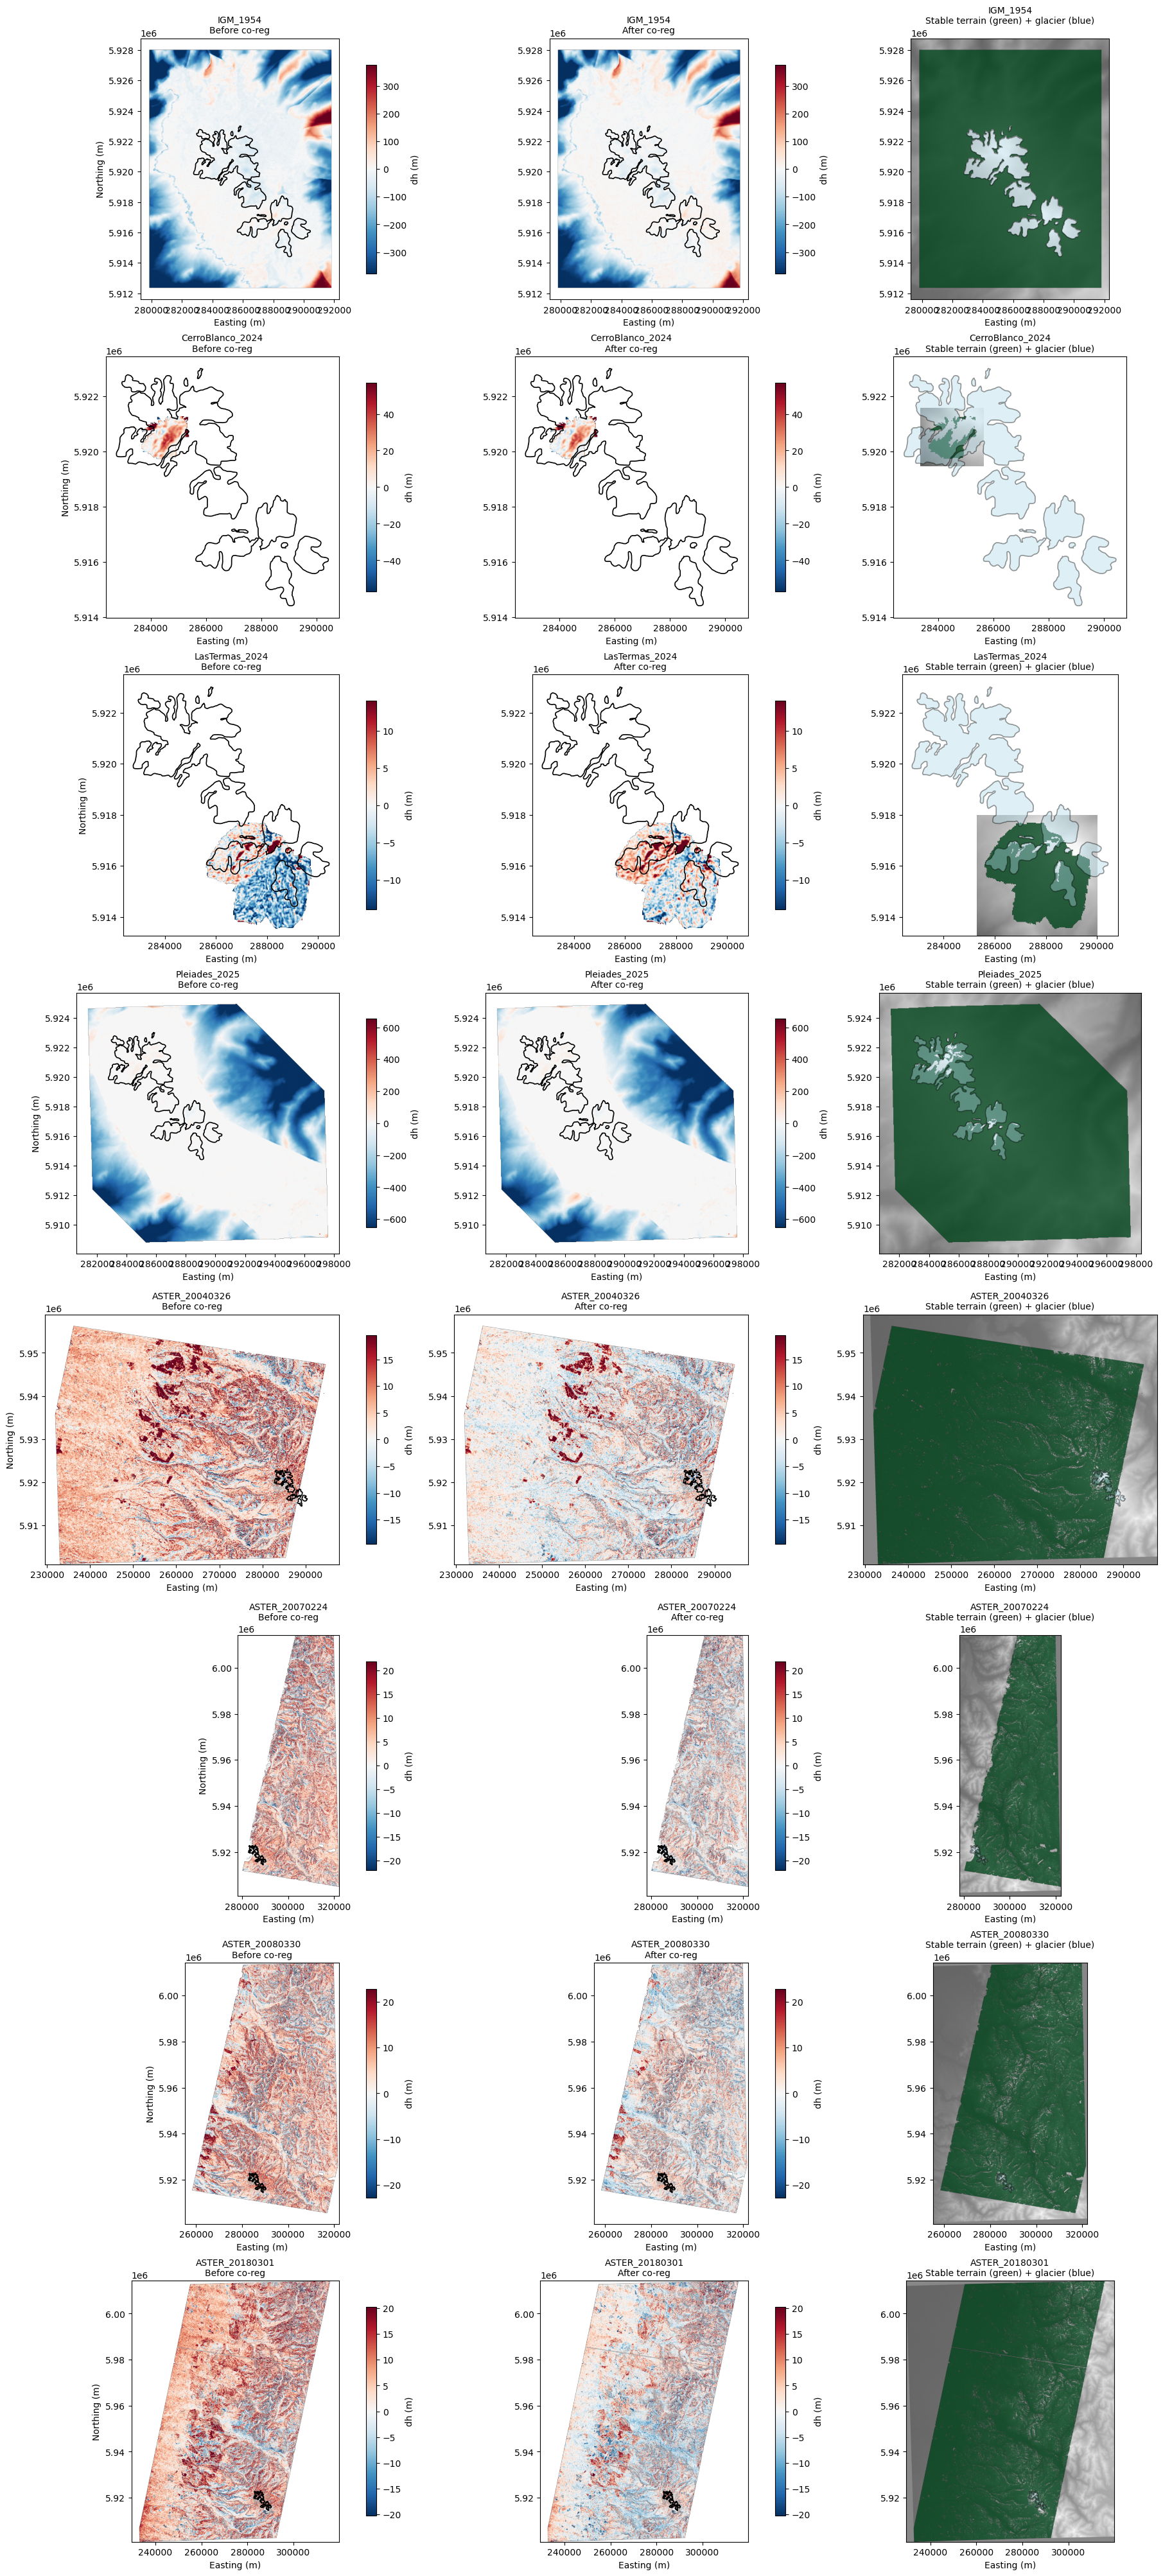

QC plot saved: coreg_dems_demcoreg/coregistration_qc.png


In [ ]:
# ==============================================================================
# Step 6: QC plots
# Three columns per DEM:
#   Col 1: full dh before co-registration (with glacier outlines)
#   Col 2: full dh after co-registration (with glacier outlines)
#   Col 3: stable terrain mask location (green) over reference DEM
# ==============================================================================

print('Generating QC plots...')

ref_path      = os.path.join(aligned_dem_folder, f'{reference_name}_aligned.tif')
reference_rxr = rxr.open_rasterio(ref_path, masked=True).squeeze()

qc_dems = ['IGM_1954', 'CerroBlanco_2024', 'LasTermas_2024', 'Pleiades_2025',
           'ASTER_20040326', 'ASTER_20070224', 'ASTER_20080330', 'ASTER_20180301']
glacier_union_gdf = gpd.read_file(glacier_union_path)

fig, axes = plt.subplots(len(qc_dems), 3,
                          figsize=(18, 5 * len(qc_dems)),
                          constrained_layout=True)

for i, dem_name in enumerate(qc_dems):
    src_path   = os.path.join(aligned_dem_folder, f'{dem_name}_aligned.tif')
    coreg_path = os.path.join(output_folder,      f'{dem_name}_coreg.tif')
    _, inlier_mask_arr = inlier_masks[dem_name]

    ref_arr = np.array(reference_dem.data).squeeze().astype(float)
    ref_arr[ref_arr > 1e10] = np.nan
    ref_arr[ref_arr < 0]    = np.nan

    with rasterio.open(src_path) as src:
        src_arr = src.read(1).astype(float)
        t, b, crs = src.transform, src.bounds, src.crs
    src_arr[src_arr > 1e10] = np.nan
    src_arr[src_arr < 0]    = np.nan

    # Snap coreg DEM to reference grid
    dem_c     = rxr.open_rasterio(coreg_path, masked=True).squeeze()
    coreg_arr = dem_c.rio.reproject_match(
        reference_rxr, resampling=Resampling.bilinear).values.astype(float)
    coreg_arr[coreg_arr > 1e10] = np.nan
    coreg_arr[coreg_arr < 0]    = np.nan

    dh_before = ref_arr - src_arr
    dh_after  = ref_arr - coreg_arr

    # Crop to valid data with padding
    vr, vc = np.where(np.isfinite(dh_before))
    if len(vr) == 0:
        continue
    r0 = max(vr.min() - max(int((vr.max()-vr.min())*0.05), 10), 0)
    r1 = min(vr.max() + max(int((vr.max()-vr.min())*0.05), 10), dh_before.shape[0])
    c0 = max(vc.min() - max(int((vc.max()-vc.min())*0.05), 10), 0)
    c1 = min(vc.max() + max(int((vc.max()-vc.min())*0.05), 10), dh_before.shape[1])
    crop = [b.left+c0*t.a, b.left+c1*t.a, b.top+r1*t.e, b.top+r0*t.e]

    finite = dh_before[np.isfinite(dh_before)]
    clim   = float(np.nanpercentile(np.abs(finite), 95)) if len(finite) > 0 else 10.0
    gv     = glacier_union_gdf.to_crs(crs)

    for j, (data, title) in enumerate([
        (dh_before, f'{dem_name}\nBefore co-reg'),
        (dh_after,  f'{dem_name}\nAfter co-reg'),
    ]):
        ax = axes[i][j]
        im = ax.imshow(data[r0:r1,c0:c1], cmap='RdBu_r', vmin=-clim, vmax=clim,
                       extent=crop, origin='upper')
        gv.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.2)
        fig.colorbar(im, ax=ax, shrink=0.8, label='dh (m)')
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('Easting (m)')
        if j == 0:
            ax.set_ylabel('Northing (m)')

    # Col 3: stable terrain mask
    ax = axes[i][2]
    rc = ref_arr[r0:r1,c0:c1].copy()
    rc[~np.isfinite(rc)] = np.nanmedian(ref_arr[np.isfinite(ref_arr)])
    ax.imshow(rc, cmap='gray', extent=crop, origin='upper', alpha=0.6)
    ax.imshow(np.where(inlier_mask_arr, 1.0, np.nan)[r0:r1,c0:c1],
              cmap='Greens', vmin=0, vmax=1, extent=crop, origin='upper', alpha=0.8)
    gv.plot(ax=ax, facecolor='lightblue', edgecolor='black', linewidth=1.2, alpha=0.4)
    ax.set_title(f'{dem_name}\nStable terrain (green) + glacier (blue)', fontsize=10)
    ax.set_xlabel('Easting (m)')

qc_path = os.path.join(output_folder, 'coregistration_qc.png')
fig.savefig(qc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'QC plot saved: {qc_path}')

In [7]:
# ==============================================================================
# Step 7 (Optional): Method comparison for a single DEM
# Uncomment to compare NuthKaab vs ICP vs VerticalShift.
# Useful for responding to reviewer requests to evaluate alternative methods.
# ==============================================================================

# COMPARE_DEM = 'IGM_1954'
# src_dem = xdem.DEM(os.path.join(aligned_dem_folder, f'{COMPARE_DEM}_aligned.tif'))
# inlier_mask_gu, inlier_mask_arr = inlier_masks[COMPARE_DEM]
#
# print(f'Method comparison for {COMPARE_DEM}:')
# for method in ['nuthkaab', 'icp', 'vshift']:
#     pl = get_coreg_pipeline(method)
#     pl.fit(reference_dem, src_dem, inlier_mask=inlier_mask_gu)
#     dem_out = pl.apply(src_dem)
#     dh  = np.array((reference_dem - dem_out).data).squeeze().astype(float)
#     dh[(dh > 1e10) | (dh < -1e4)] = np.nan
#     nmad = gu.stats.nmad(dh[inlier_mask_arr][np.isfinite(dh[inlier_mask_arr])])
#     aff  = pl.meta.get('outputs', {}).get('affine', {})
#     print(f'  {method:12s}  NMAD: {nmad:.3f} m  '
#           f'dx: {aff.get("shift_x","?"):.2f}  '
#           f'dy: {aff.get("shift_y","?"):.2f}  '
#           f'dz: {aff.get("shift_z","?"):.2f}')

print('Notebook 2 complete. Co-registered DEMs saved to:', output_folder)
print('Pass', output_folder, 'to Notebook 3 for differencing and uncertainty analysis.')

Notebook 2 complete. Co-registered DEMs saved to: coreg_dems_demcoreg
Pass coreg_dems_demcoreg to Notebook 3 for differencing and uncertainty analysis.
